# Unique Presence Constraint

Goal: demonstrate, on a hand-built instance, that each VM is placed exactly once by the three solvers: FFD, PLNE and CP-SAT.

In [2]:
from IPython.display import display

from vm_allocation.models import Context, Server, VM
from vm_allocation.solvers import CPSATSolver, FFDSolver, PLNESolver

## Demo Instance

The data is intentionally small and deterministic. The servers have enough capacity for several placements to be possible; the property tested here is only: no missing VM, no duplicated VM.

Available servers:
- s1: cpu=10, ram=16, storage=100, bw=20
- s2: cpu=10, ram=16, storage=100, bw=20
- s3: cpu=10, ram=16, storage=100, bw=20

VMs to place:
- 1: cpu=4, ram=4, storage=20, bw=5
- 2: cpu=5, ram=6, storage=30, bw=4
- 3: cpu=3, ram=2, storage=10, bw=3
- 4: cpu=4, ram=5, storage=25, bw=4
- 5: cpu=2, ram=2, storage=10, bw=2


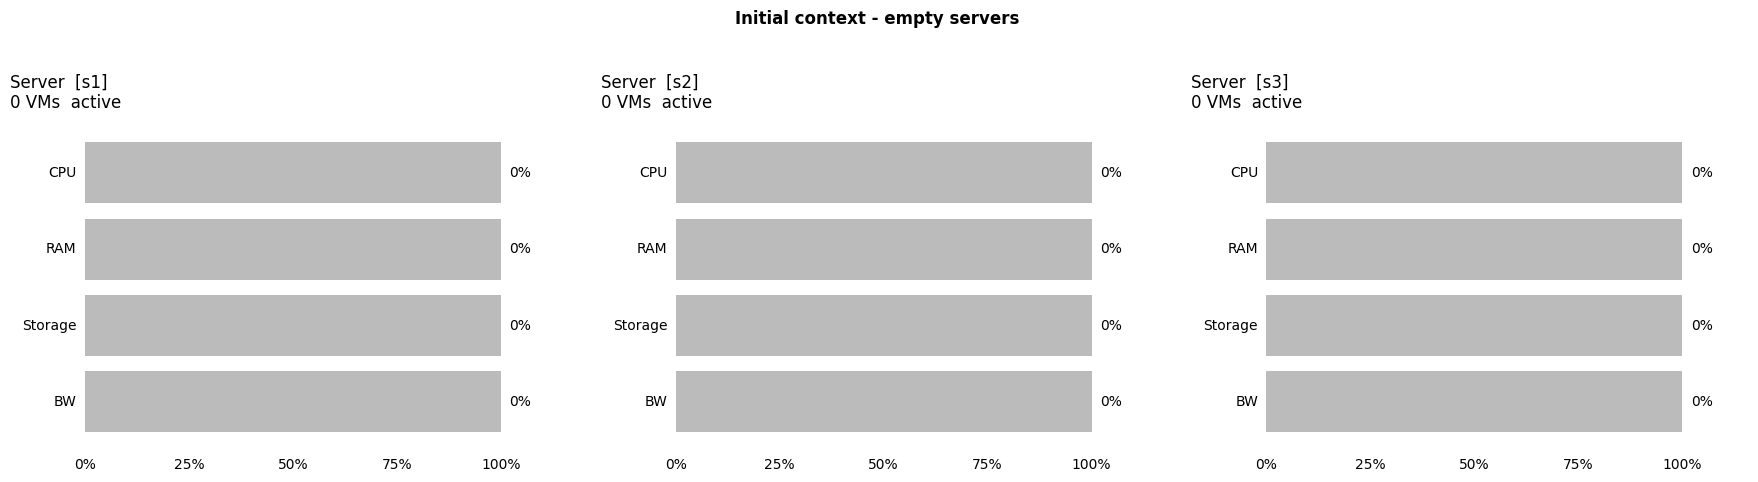

In [3]:
SERVERS = [
    Server("s1", cpu=10, ram=16, storage=100, bw=20),
    Server("s2", cpu=10, ram=16, storage=100, bw=20),
    Server("s3", cpu=10, ram=16, storage=100, bw=20),
]

VMS = [
    VM("1", cpu=4, ram=4, storage=20, bw=5),
    VM("2", cpu=5, ram=6, storage=30, bw=4),
    VM("3", cpu=3, ram=2, storage=10, bw=3),
    VM("4", cpu=4, ram=5, storage=25, bw=4),
    VM("5", cpu=2, ram=2, storage=10, bw=2),
]

SOLVERS = {
    "FFD": FFDSolver(),
    "PLNE": PLNESolver(),
    "CP-SAT": CPSATSolver(migration_weight=0, fragmentation_weight=0),
}


def copies(items):
    return [item.copy() for item in items]


print("Available servers:")
for server in SERVERS:
    print(f"- {server.id}: cpu={server.cpu_capacity}, ram={server.ram_capacity}, storage={server.storage_capacity}, bw={server.bw_capacity}")

print("\nVMs to place:")
for vm in VMS:
    print(f"- {vm.id}: cpu={vm.cpu}, ram={vm.ram}, storage={vm.storage}, bw={vm.bw}")

display(Context(copies(SERVERS)).plot("Initial context - empty servers"))

## Constraint Check

For each solution, we count how many times each VM appears across all servers. The unique presence constraint is satisfied if every expected VM appears exactly once.


===== FFD CLEAN SOLVER =====
[DEBUG] total VMs = 5

FFD - occurrences per VM
VM          occurrences
-----------------------
1           1
2           1
3           1
4           1
5           1


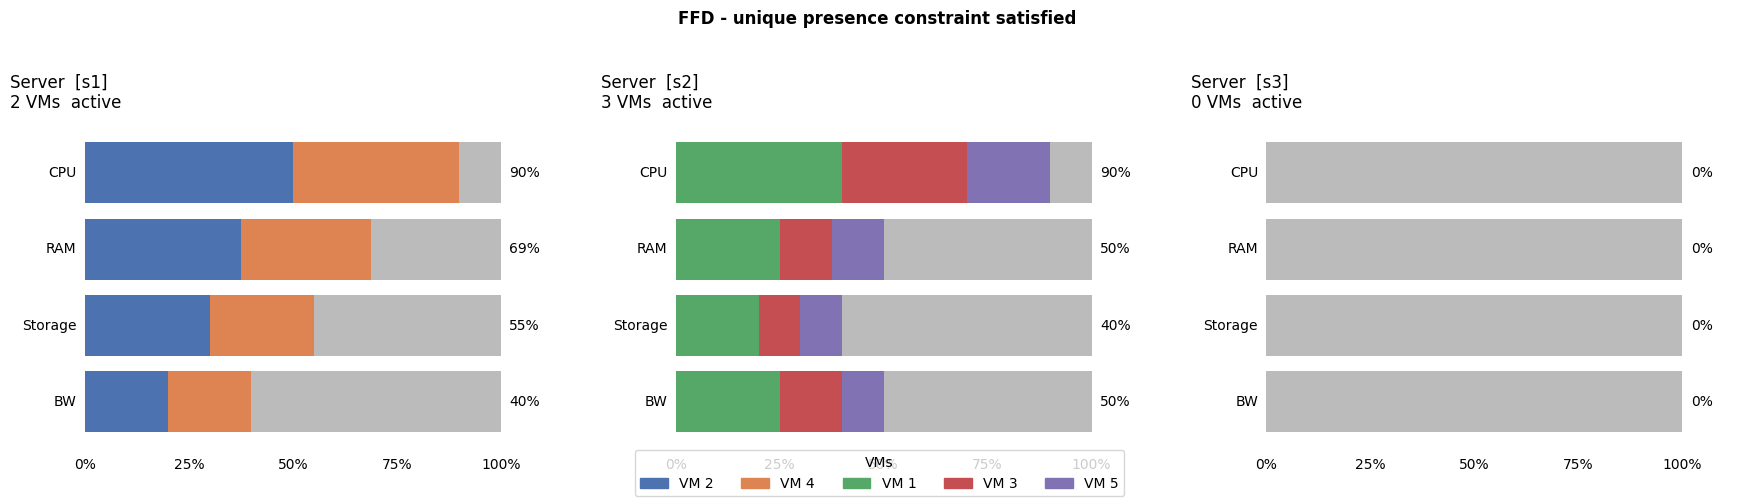


PLNE - occurrences per VM
VM          occurrences
-----------------------
1           1
2           1
3           1
4           1
5           1


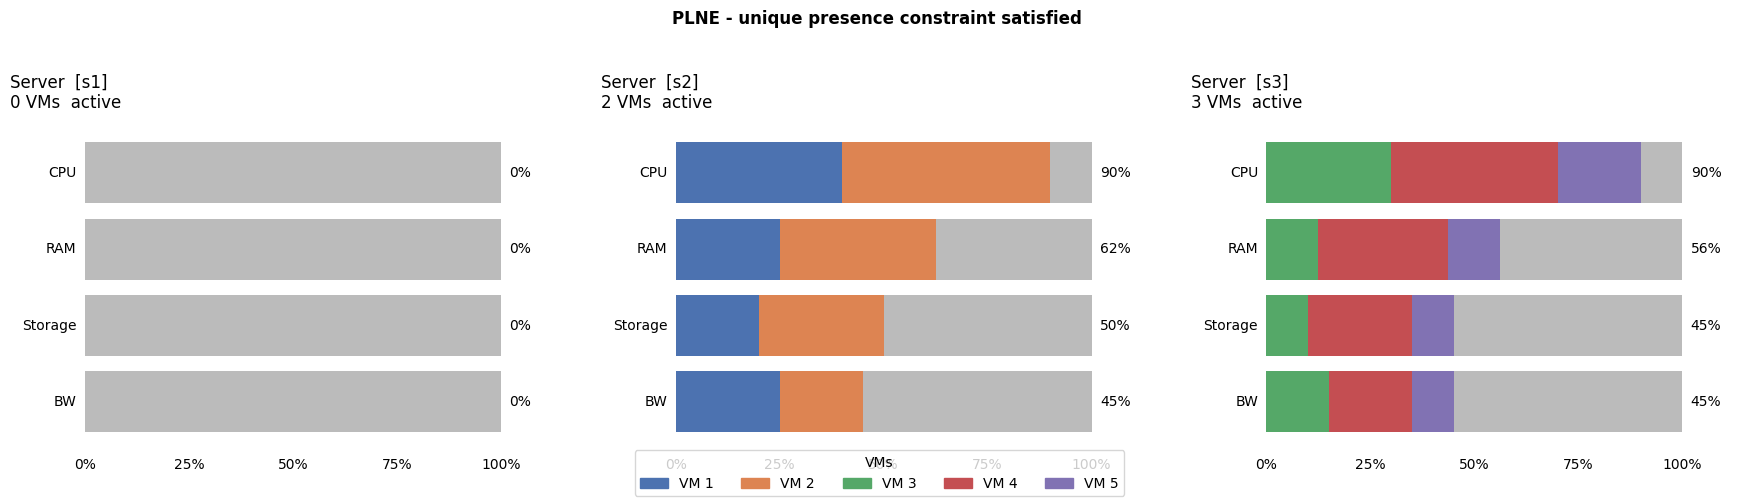


CP-SAT - occurrences per VM
VM          occurrences
-----------------------
1           1
2           1
3           1
4           1
5           1


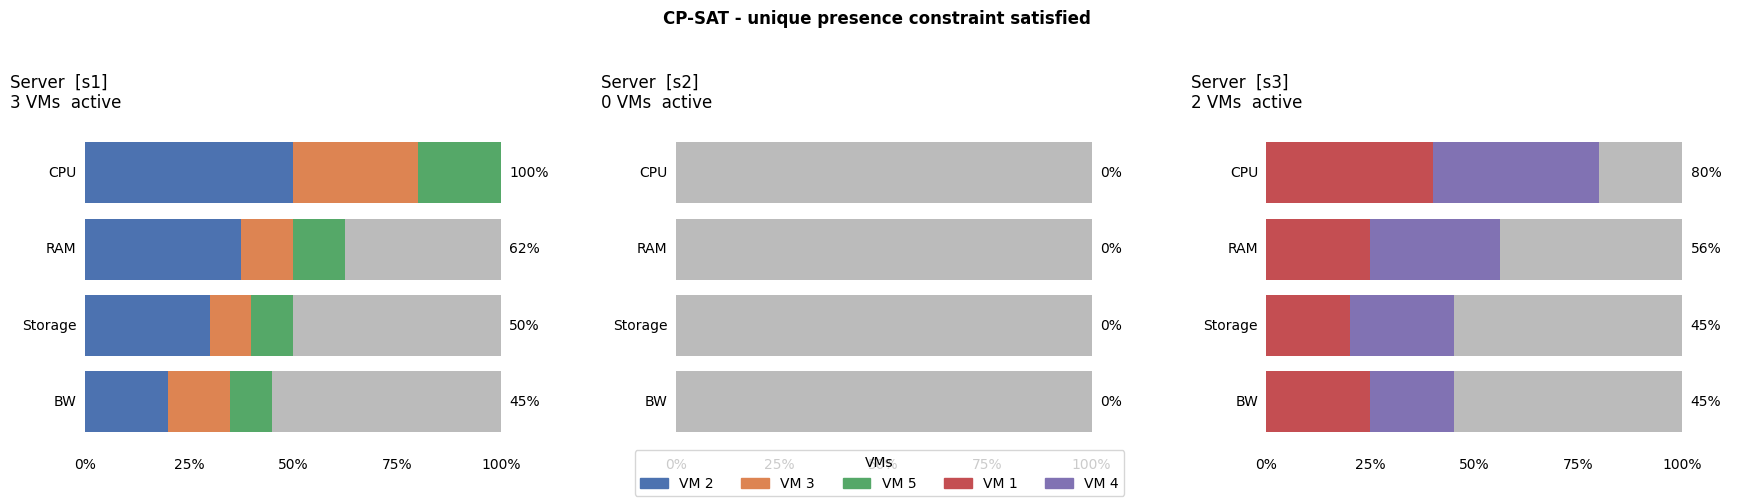


All solvers place each VM exactly once.


In [4]:
expected_ids = [vm.id for vm in VMS]
solutions = {}

for solver_name, solver in SOLVERS.items():
    solution = solver.solve(copies(VMS), Context(copies(SERVERS)))
    assert solution is not None, f"{solver_name} did not find a solution"

    counts = {vm_id: 0 for vm_id in expected_ids}

    for server in solution.get_servers():
        for vm in server.vms:
            counts[vm.id] += 1

    assert all(count == 1 for count in counts.values()), counts
    solutions[solver_name] = solution

    print(f"\n{solver_name} - occurrences per VM")
    print("VM          occurrences")
    print("-----------------------")
    for vm_id, count in sorted(counts.items()):
        print(f"{vm_id:<12}{count}")

    display(solution.plot(f"{solver_name} - unique presence constraint satisfied"))

print("\nAll solvers place each VM exactly once.")

## Placement Details

In [53]:
for solver_name, solution in solutions.items():
    print(f"\n===== {solver_name} =====")
    print(solution)


===== FFD =====
===== Context - 3 servers, 5 VMs total =====

┌─ Server [s1] ─── 2 VMs ──────────────────────────────────────────────────────────────────────┐
│  CPU     [██████████████████████████████████████████████████████████░░░░░░]     9/10  ( 90%) │
│  RAM     [████████████████████████████████████████████░░░░░░░░░░░░░░░░░░░░]    11/16  ( 69%) │
│  Storage [███████████████████████████████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   55/100  ( 55%) │
│  BW      [██████████████████████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]     8/20  ( 40%) │
│  VMs:                                                                                        │
│    · VM[2](cpu=5, ram=6, sto=30, bw=4)                                                       │
│    · VM[4](cpu=4, ram=5, sto=25, bw=4)                                                       │
└──────────────────────────────────────────────────────────────────────────────────────────────┘

┌─ Server [s2] ─── 3 VMs ──────────────────────────────────────